# Week 5: Data Visualization & Storytelling

**Dataset:** `diabetes_risk_clean.csv` (from Week 2)
**Author:** [Whitney Waithera]
**Date:** [1st october]

## Objective
In Week 4, I used statistics to *find* insights. This week, my goal is to use Matplotlib and Seaborn to *communicate* those insights to a non-technical audience. 
I will:
1. Create advanced visualizations (Violin plots, Joint plots, Multivariate plots).
2. Build a single, unified "Dashboard" image.
3. Write a Visual Analytics Report summarizing the key findings.

## 1. Data Loading and Preparation

I will load the cleaned dataset from Week 2. This ensures that I am not visualizing missing values, outliers, or inconsistent text categories.

I will also set a professional `seaborn` theme to ensure the plots look clean and ready for presentation.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set a professional style for all plots
sns.set_theme(style="whitegrid", palette="muted")

# Load the cleaned dataset from Week 2 from either the notebook or workspace root
data_candidates = [
    Path("../ds-attachment-week1/week2_data_cleaning/diabetes_risk_clean.csv"),
    Path("ds-attachment-week1/week2_data_cleaning/diabetes_risk_clean.csv"),
]
data_path = next((candidate for candidate in data_candidates if candidate.exists()), None)
if data_path is None:
    raise FileNotFoundError("Could not find diabetes_risk_clean.csv in the Week 2 data folder.")
df = pd.read_csv(data_path)

print("Data loaded successfully. Shape:", df.shape)

Data loaded successfully. Shape: (15000, 22)


## 2. Advanced Visualizations (Telling the Story)

Basic bar charts and histograms are a good start, but to truly understand the data, I need to visualize distributions and relationships simultaneously.

*   **Violin Plots:** Unlike box plots that only show quartiles, violin plots show the *full density* of the data. This helps me see if the data is skewed or has multiple peaks.
*   **Joint Plots:** This combines a scatter plot with marginal histograms. It is the perfect tool for understanding the relationship between two key clinical variables (like Fasting Blood Sugar and HBA1C) while also seeing how they are distributed.
*   **Multivariate Count Plots:** By adding a `hue` parameter, I can see how a third categorical variable (Income Bracket) breaks down within a primary category (Diet Type).

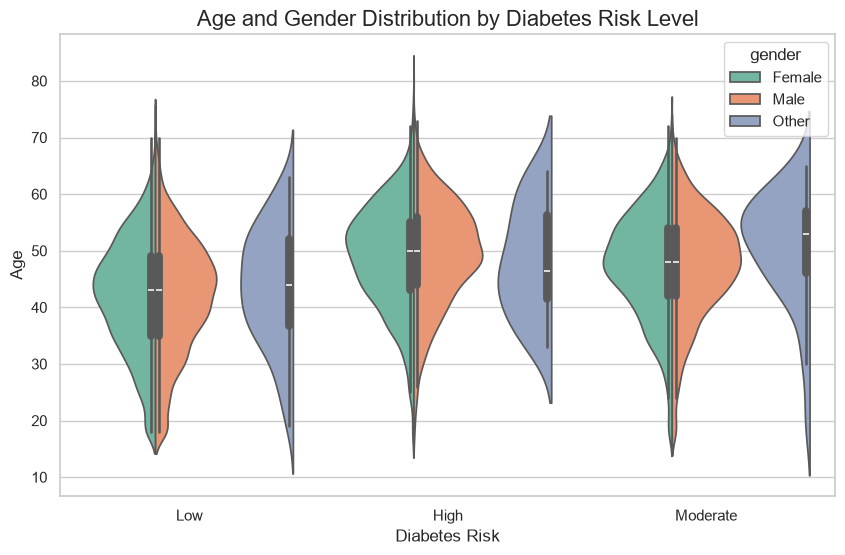

In [9]:
plt.figure(figsize=(10, 6))

# Compare Age distribution across Diabetes Risk levels
sns.violinplot(data=df, x='diabetes_risk', y='age', hue='gender', split=True, palette='Set2')

plt.title('Age and Gender Distribution by Diabetes Risk Level', fontsize=16)
plt.xlabel('Diabetes Risk', fontsize=12)
plt.ylabel('Age', fontsize=12)
plt.show()

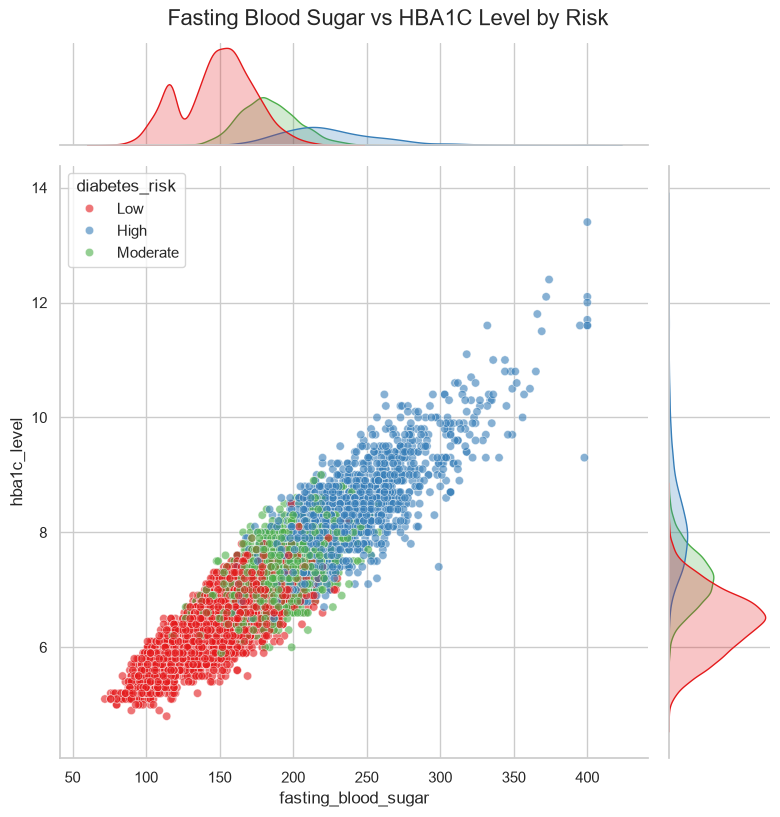

In [10]:
# Joint plot of Fasting Blood Sugar vs HBA1C Level, colored by Risk
sns.jointplot(data=df, x='fasting_blood_sugar', y='hba1c_level', hue='diabetes_risk', palette='Set1', height=8, alpha=0.6)

plt.suptitle('Fasting Blood Sugar vs HBA1C Level by Risk', y=1.02, fontsize=16)
plt.show()

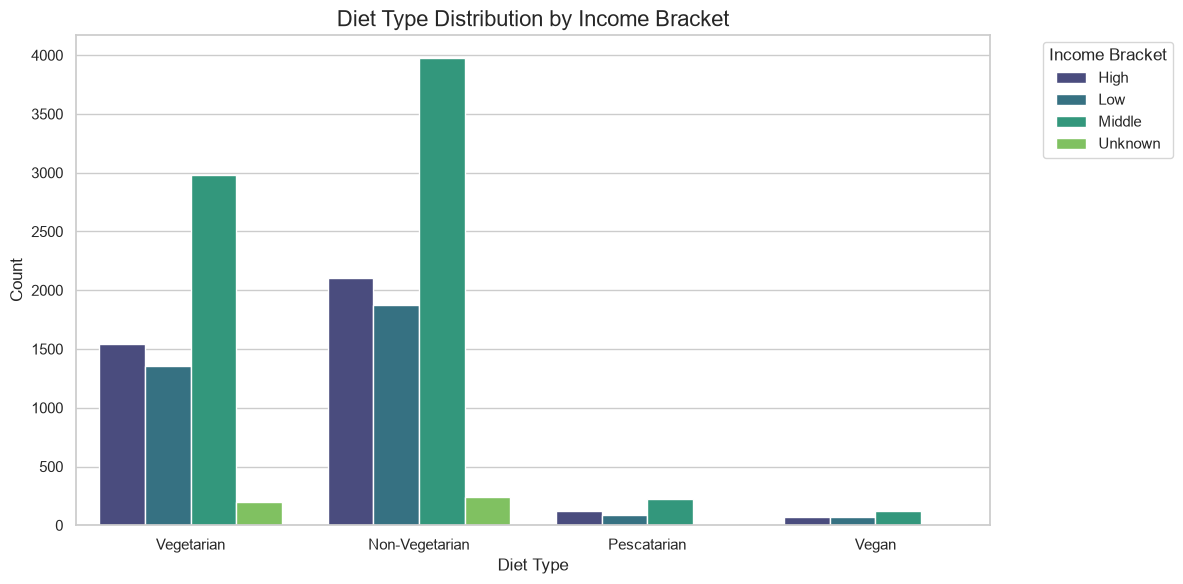

In [11]:
plt.figure(figsize=(12, 6))

# Count of diet types, separated by income bracket, stacked by risk
sns.countplot(data=df, x='diet_type', hue='income_bracket', palette='viridis')

plt.title('Diet Type Distribution by Income Bracket', fontsize=16)
plt.xlabel('Diet Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Income Bracket', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
## 3. Building the Visual Dashboard

# I will combine the four most important visualizations into a single 2×2 grid.

# I will also export this dashboard as a high-resolution PNG file (`week5_dashboard.png`) to include in my GitHub portfolio.

SyntaxError: invalid character '×' (U+00D7) (2298177894.py, line 3)

In [ ]:
# Create a 2x2 grid of plots
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Diabetes Risk Visual Analytics Dashboard', fontsize=20, fontweight='bold')

# Plot 1: Diabetes Risk Distribution (Pie Chart)
risk_counts = df['diabetes_risk'].value_counts()
axes[0, 0].pie(risk_counts, labels=risk_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("pastel"))
axes[0, 0].set_title('1. Overall Diabetes Risk Distribution', fontsize=14)

# Plot 2: BMI vs Age Scatter (colored by Risk)
sns.scatterplot(data=df, x='age', y='bmi', hue='diabetes_risk', palette='Set1', alpha=0.6, ax=axes[0, 1])
axes[0, 1].set_title('2. BMI vs Age by Risk Level', fontsize=14)

# Plot 3: Average Fasting Blood Sugar by Physical Activity
sns.barplot(data=df, x='physical_activity_level', y='fasting_blood_sugar', estimator='mean', errorbar=None, palette='Set2', ax=axes[1, 0])
axes[1, 0].set_title('3. Average Fasting Blood Sugar by Activity Level', fontsize=14)

# Plot 4: Correlation Heatmap (Simplified)
numerical_df = df.select_dtypes(include=['number'])
corr = numerical_df.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', ax=axes[1, 1])
axes[1, 1].set_title('4. Feature Correlation Heatmap', fontsize=14)

plt.tight_layout()
plt.subplots_adjust(top=0.92) # Adjust title space
plt.savefig('week5_dashboard.png', dpi=300, bbox_inches='tight') # Save the image!
plt.show()

#  Visual Analytics Report: Diabetes Risk

# Introduction
The following report visualizes key trends in the diabetes risk dataset. The goal is to identify the most critical factors contributing to diabetes risk to inform preventative healthcare strategies.

# Key Insights from the Dashboard
1. **Risk Distribution:** The majority of the population falls into the "Low" risk category (see Pie Chart). However, the "High" and "Moderate" categories represent a significant portion of the population that requires attention.
2. **Age & BMI Correlation:** The scatter plot confirms that higher BMI and older age are strongly correlated with "High" diabetes risk. This suggests that weight management and age-specific screening are critical.
3. **Physical Activity Impact:** The bar chart shows a clear trend: individuals with a "Sedentary" lifestyle have significantly higher average fasting blood sugar levels compared to those who are "Active." This highlights physical activity as a key preventative measure.
4. **Feature Correlation:** The heatmap confirms that `fasting_blood_sugar` and `hba1c_level` are the strongest indicators of diabetes risk.

# Recommendations
- Implement targeted screening programs for older adults with high BMI.
- Promote physical activity initiatives, especially for sedentary populations.